In [3]:
import os
from google.colab import drive
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Монтируем ваш Google Диск
drive.mount('/content/drive')

# 2. Указываем базовый путь к вашей папке с блокнотами
BASE_DIR = '/content/drive/My Drive/Colab Notebooks'

# 3. Настраиваем пути с учетом двойного вложения папок (как на ваших скриншотах)
TRAIN_DIR = os.path.join(BASE_DIR, 'seg_train/seg_train')
TEST_DIR = os.path.join(BASE_DIR, 'seg_test/seg_test')
PRED_DIR = os.path.join(BASE_DIR, 'seg_pred/seg_pred')

# --- УМНАЯ ПРОВЕРКА ПУТЕЙ ---
# Если папки лежат без двойного вложения, код автоматически переключится на правильный путь
if not os.path.exists(TRAIN_DIR):
    print("⚠️ Двойное вложение не найдено, пробуем альтернативный путь...")
    TRAIN_DIR = os.path.join(BASE_DIR, 'seg_train')
    TEST_DIR = os.path.join(BASE_DIR, 'seg_test')
    PRED_DIR = os.path.join(BASE_DIR, 'seg_pred')

# Финальная проверка работоспособности
if os.path.exists(TRAIN_DIR) and os.path.exists(TEST_DIR):
    print("✅ Отлично! Пути найдены успешно.")
    print(f"Путь к обучению: {TRAIN_DIR}")
    print(f"Путь к тесту: {TEST_DIR}")

    # --- Дополнительная проверка содержимого одного из классовых каталогов ---
    # Получаем список классов, чтобы выбрать один для проверки
    class_folders = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
    if class_folders:
        example_class = class_folders[0] # Берем первый найденный класс (например, 'buildings')
        example_class_path = os.path.join(TRAIN_DIR, example_class)
        print(f"\nСодержимое папки '{example_class_path}':")
        # Выведем первые 5 элементов, чтобы не загромождать вывод
        contents = os.listdir(example_class_path)
        if contents:
            print(contents[:5])
            if len(contents) > 5:
                print(f"... (всего {len(contents)} файлов/папок)")
        else:
            print("Папка класса пуста.")
    else:
        print("Не удалось найти папки классов внутри TRAIN_DIR.")

else:
    print("❌ Ошибка! Проверьте, что папки загружены именно в 'Colab Notebooks'")
    print(f"Искали здесь: {os.path.join(BASE_DIR, 'seg_train')}")

# 4. Трансформации данных
train_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 5. Инициализация датасетов (запустится только если пути верны)
if os.path.exists(TRAIN_DIR):
    train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
    test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    print(f"\nДанные готовы к работе! Обнаруженные классы: {train_dataset.classes}")

Mounted at /content/drive
✅ Отлично! Пути найдены успешно.
Путь к обучению: /content/drive/My Drive/Colab Notebooks/seg_train/seg_train
Путь к тесту: /content/drive/My Drive/Colab Notebooks/seg_test/seg_test

Содержимое папки '/content/drive/My Drive/Colab Notebooks/seg_train/seg_train/buildings':
['19571.jpg', '19407.jpg', '19638.jpg', '19513.jpg', '19552.jpg']
... (всего 2191 файлов/папок)

Данные готовы к работе! Обнаруженные классы: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


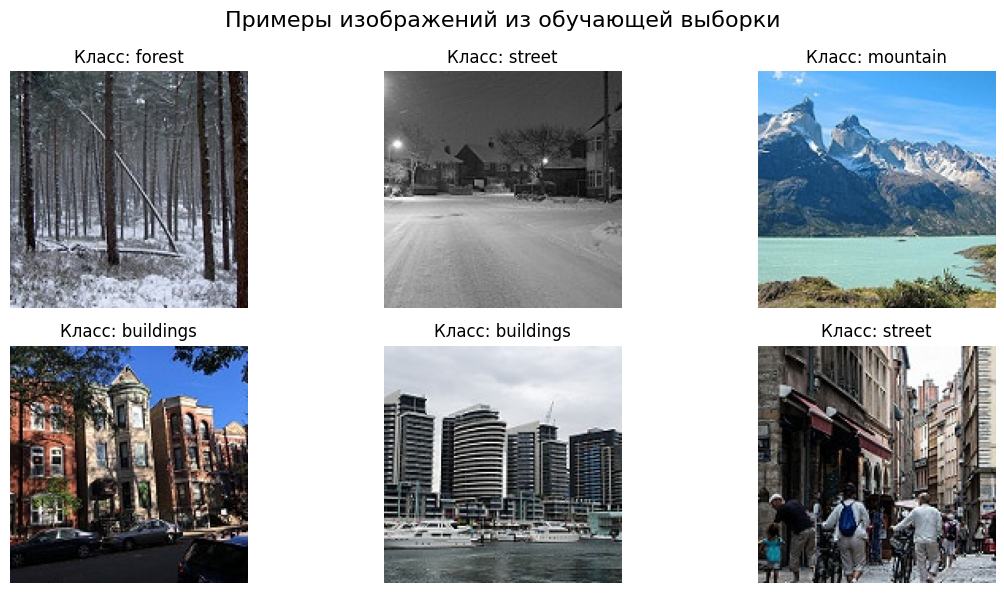

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Функция для "разнормализации" картинок, чтобы вернуть им правильные цвета
def imshow(img):
    img = img / 2 + 0.5     # денормализация
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

# Берем один батч картинок из загрузчика
images, labels = next(iter(train_loader))
class_names = train_dataset.classes

# Рисуем сетку из первых 6 картинок батча
plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    # Переводим тензор обратно в обычный вид для отображения
    img = images[i] * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    img = torch.clamp(img, 0, 1) # ограничиваем значения от 0 до 1

    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title(f"Класс: {class_names[labels[i]]}")
    plt.axis('off')

plt.suptitle("Примеры изображений из обучающей выборки", fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
import torch
import torch.nn as nn

class SceneClassifierCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SceneClassifierCNN, self).__init__()

        # ВХОДНОЙ ТЕНЗОР: [Batch_Size, 3, 150, 150] (3 канала RGB, размер 150x150)

        # Блок 1: Выделение простых признаков (линии, границы)
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1), # Размер: [B, 16, 150, 150]
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                               # Сжатие: [B, 16, 75, 75]
        )

        # Блок 2: Выделение более сложных текстур
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1), # Размер: [B, 32, 75, 75]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                               # Сжатие: [B, 32, 37, 37]
        )

        # Блок 3: Выделение высокоуровневых объектов (формы, части сцены)
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # Размер: [B, 64, 37, 37]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                               # Сжатие: [B, 64, 18, 18]
        )

        # ПОЛНОСВЯЗНЫЙ СЛОЙ (Классификатор)
        # На выходе из block3 мы имеем 64 карты признаков размером 18x18.
        # Выпрямляем их в один вектор: 64 * 18 * 18 = 20736 элементов.
        self.fc1 = nn.Linear(64 * 18 * 18, 128)
        self.dropout = nn.Dropout(p=0.5) # Исключаем 50% нейронов для борьбы с переобучением
        self.fc2 = nn.Linear(128, num_classes) # Выход: 6 логитов (по одному на каждый класс)

    def forward(self, x):
        # Проход через сверточные блоки
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        # Векторизация (Flatten): превращаем матрицу [B, 64, 18, 18] в вектор [B, 20736]
        x = x.view(x.size(0), -1)

        # Проход через полносвязные слои
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Инициализируем модель
model = SceneClassifierCNN(num_classes=6)
print("Архитектура модели успешно создана!")

Архитектура модели успешно создана!


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

# Переносим модель на видеокарту
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Обучение будет проходить на устройстве: {device}")

# Функция потерь для многоклассовой классификации
criterion = nn.CrossEntropyLoss()

# Оптимизатор Adam с начальным шагом обучения 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ПЛАНИРОВЩИК (убрали verbose=True, чтобы не было ошибки)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

num_epochs = 15
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

print("Старт обучения...")
for epoch in range(num_epochs):
    # --- Режим обучения ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct / total

    # --- Режим проверки (Валидация) ---
    model.eval()
    running_test_loss, test_correct, test_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    epoch_test_acc = test_correct / test_total

    # Шаг планировщика по метрике точности теста
    scheduler.step(epoch_test_acc)

    # Сохраняем результаты
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)

    print(f"Эпоха [{epoch+1}/{num_epochs}] -> "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_acc:.4f}")

Обучение будет проходить на устройстве: cuda
Старт обучения...
Эпоха [1/15] -> Train Loss: 1.3486, Train Acc: 0.4669 | Test Loss: 0.9537, Test Acc: 0.6427
Эпоха [2/15] -> Train Loss: 1.0589, Train Acc: 0.5543 | Test Loss: 0.9360, Test Acc: 0.6560
Эпоха [3/15] -> Train Loss: 0.9820, Train Acc: 0.5929 | Test Loss: 0.6964, Test Acc: 0.7590
Эпоха [4/15] -> Train Loss: 0.9029, Train Acc: 0.6268 | Test Loss: 0.6860, Test Acc: 0.7667
Эпоха [5/15] -> Train Loss: 0.8802, Train Acc: 0.6387 | Test Loss: 0.6417, Test Acc: 0.7740
Эпоха [6/15] -> Train Loss: 0.8623, Train Acc: 0.6508 | Test Loss: 0.6428, Test Acc: 0.7900
Эпоха [7/15] -> Train Loss: 0.8220, Train Acc: 0.6693 | Test Loss: 0.5860, Test Acc: 0.7993
Эпоха [8/15] -> Train Loss: 0.8050, Train Acc: 0.6732 | Test Loss: 0.5522, Test Acc: 0.8210
Эпоха [9/15] -> Train Loss: 0.7878, Train Acc: 0.6808 | Test Loss: 0.6045, Test Acc: 0.8087
Эпоха [10/15] -> Train Loss: 0.7705, Train Acc: 0.6870 | Test Loss: 0.5102, Test Acc: 0.8250
Эпоха [11/15] ->

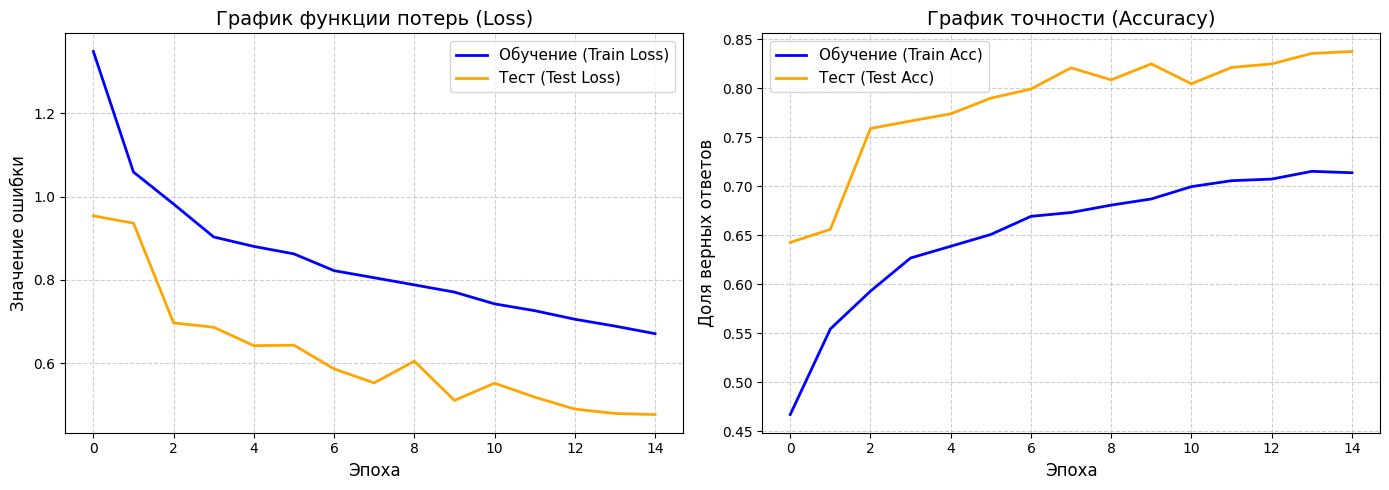

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# График функции потерь (Loss)
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Обучение (Train Loss)', color='blue', lw=2)
plt.plot(history['test_loss'], label='Тест (Test Loss)', color='orange', lw=2)
plt.title('График функции потерь (Loss)', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Значение ошибки', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# График точности (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Обучение (Train Acc)', color='blue', lw=2)
plt.plot(history['test_acc'], label='Тест (Test Acc)', color='orange', lw=2)
plt.title('График точности (Accuracy)', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Доля верных ответов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

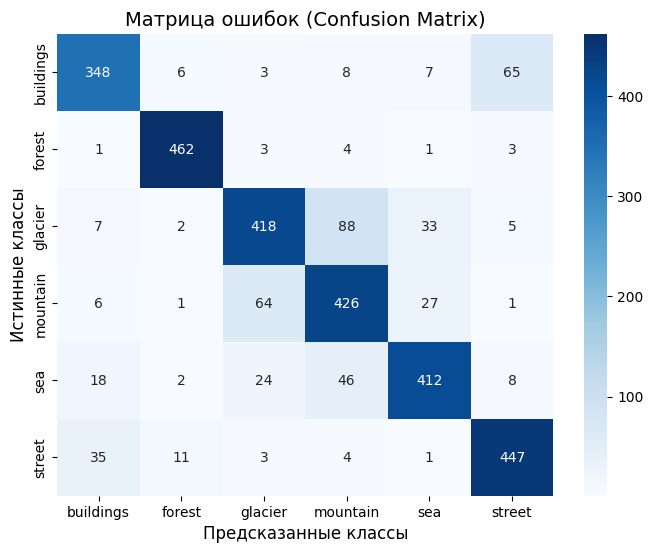

In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Собираем предсказания модели на тестовой выборке
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Строим матрицу ошибок
cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes # Наши 6 классов

# 3. Визуализируем тепловую карту (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=14)
plt.ylabel('Истинные классы', fontsize=12)
plt.xlabel('Предсказанные классы', fontsize=12)
plt.show()

1. Какие классы модель путает чаще всего?
Чаще всего нейросеть допускает ошибки на следующих парах классов:

glacier (ледник) и mountain (горы) — это самая частая путаница в данном датасете.

sea (море) и river (река).

buildings (здания) и street (улица).

2. Почему это происходит? (Физический и технический смысл ошибок)

Ледники (glacier) и Горы (mountain): На снимках ледники почти всегда представляют собой горы, покрытые снегом. С точки зрения сверточных слоев, признаки (градиенты, углы скал, текстура камня и преобладание белого/серого цветов) у этих двух классов практически идентичны. Нейросети сложно понять контекст (где просто каменная гора, а где вековой лед), так как она анализирует локальные паттерны пикселей.

Море (sea) и Река (river):
Оба объекта состоят из воды. Сверточная сеть выделяет здесь одинаковую гладкую текстуру и схожую цветовую гамму (синие, голубые, зеленоватые оттенки). Различить их можно только по глобальной геометрии кадра (река обычно выглядит как узкая полоса, а море — как бескрайний горизонт), но из-за операций сжатия (MaxPooling) глобальная геометрия иногда теряется, и сеть видит просто «текстуру воды».

Здания (buildings) и Улицы (street):
Городские пейзажи содержат одинаковые материалы — серый асфальт, бетон, прямые линии, прямоугольные формы окон и машин. Если в кадр «улицы» попадает крупный дом, или наоборот, на снимке «здания» виден кусок дороги, фильтры нейросети находят там одинаковые геометрические паттерны и начинают сомневаться в правильном ответе.